# Phase 2 — Parameter Sensitivity Sweep

Sweeps four cascade parameters independently to demonstrate robustness:

| Parameter | Sweep values | Fixed value |
|-----------|-------------|-------------|
| **γ** (energy Pfa) | [0.01, 0.05, 0.10, 0.20] | 0.05 |
| **min_burst_len** | [10, 20, 50, 100] | 50 |
| **Nfft** (SCF window) | [128, 256, 512, 1024] | 512 |
| **min_duration** (segment aggregation) | [0.005, 0.025, 0.10, 0.50] s | 0.10 s |

Each sweep is self-contained — run sections independently if needed.

**Expected runtime:** ~1 h per sweep (γ, mbl, Nfft); ~1 min for duration sweep.  
All outputs → `results/review_1/`

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from pathlib import Path
from dotenv import load_dotenv
from sklearn.metrics import roc_curve, auc
from tqdm import tqdm

ROOT = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT / "src"))

from rfml_uav.drone_rf.consts import BUI, FS_HZ
from rfml_uav.drone_rf.utils import get_segment_count, get_binary_label
from rfml_uav.signal_detection.methods import energy_detector, cyclo_detector
from rfml_uav.signal_detection.cascade import aggregate_bursts

load_dotenv()
CHUNKED_PATH = Path(os.getenv("DATA_PATH")) / "chunked"
OUT = ROOT / "results" / "review_1"
OUT.mkdir(parents=True, exist_ok=True)

np.random.seed(42)

BG_BUI       = "00000"
CHUNK_LEN    = 4000
CHUNK_DUR    = CHUNK_LEN / FS_HZ   # seconds

FIXED_PFA    = 0.05
FIXED_MBL    = 50
FIXED_NFFT   = 512
FIXED_MINDUR = 0.10

print(f"ROOT         : {ROOT}")
print(f"CHUNKED_PATH : {CHUNKED_PATH}")
print(f"FS_HZ        : {FS_HZ/1e6:.0f} MHz")
print(f"chunk_dur    : {CHUNK_DUR*1e6:.1f} μs")

ROOT         : /home/ivan/work/ml/rfml-uav
CHUNKED_PATH : /home/ivan/work/ml/rfml-uav/data/drone-rf/chunked
FS_HZ        : 80 MHz
chunk_dur    : 50.0 μs


## Precompute background energy scores

Run once — all sweeps use these to derive energy threshold at each γ value.

In [2]:
print("Loading background energy scores...")
bg_energy = []
for seg in range(get_segment_count(BG_BUI)):
    for fp in sorted(glob(str(CHUNKED_PATH / f"{BG_BUI}*_{seg}.npz"))):
        chunks = np.load(fp)["arr_0"]
        bg_energy.extend(energy_detector(x) for x in chunks)
bg_energy = np.array(bg_energy)
print(f"Background chunks : {len(bg_energy)}")

def get_threshold(pfa):
    return float(np.percentile(bg_energy, 100 * (1 - pfa)))

thr_fixed = get_threshold(FIXED_PFA)
print(f"Fixed thr (Pfa={FIXED_PFA}) : {thr_fixed:.6f}")

Loading background energy scores...
Background chunks : 205000
Fixed thr (Pfa=0.05) : 14.769512


## Core evaluation helper

In [3]:
def evaluate_cascade(thr, mbl, nfft, label_str=""):
    """Segment-level cascade evaluation. Returns metrics dict."""
    seg_scores, seg_labels = [], []
    inv_signal, tot_signal = 0, 0
    inv_noise,  tot_noise  = 0, 0

    for bui in tqdm(BUI, desc=label_str or f"thr={thr:.3f} mbl={mbl} nfft={nfft}"):
        label = get_binary_label(bui)
        for seg in range(get_segment_count(bui)):
            files = sorted(glob(str(CHUNKED_PATH / f"{bui}*_{seg}.npz")))
            if not files:
                continue

            all_scores, invoked = [], False
            for fp in files:
                chunks = np.load(fp)["arr_0"]
                decisions = [energy_detector(x) >= thr for x in chunks]
                bursts = aggregate_bursts(decisions, min_len=mbl)
                if bursts:
                    invoked = True
                    c_scores = [
                        cyclo_detector(np.concatenate(chunks[b0:b1]), fs=FS_HZ, Nfft=nfft)
                        for b0, b1 in bursts
                    ]
                    all_scores.append(max(c_scores))

            seg_scores.append(max(all_scores) if all_scores else 0.0)
            seg_labels.append(label)
            if label == 1:
                tot_signal += 1; inv_signal += int(invoked)
            else:
                tot_noise  += 1; inv_noise  += int(invoked)

    seg_scores = np.array(seg_scores)
    seg_labels = np.array(seg_labels)
    fpr, tpr, _ = roc_curve(seg_labels, seg_scores)
    roc_auc = auc(fpr, tpr)
    ok = np.where(fpr <= FIXED_PFA)[0]
    i  = ok[np.argmax(tpr[ok])] if len(ok) else np.argmin(fpr)
    return {
        "AUC":        roc_auc,
        "Pd":         float(tpr[i]),
        "Pfa_op":     float(fpr[i]),
        "inv_signal": inv_signal / tot_signal if tot_signal else 0.0,
        "inv_noise":  inv_noise  / tot_noise  if tot_noise  else 0.0,
        "_fpr": fpr, "_tpr": tpr,
    }


def sweep_plot(param_vals, records, param_name, param_label, fname, fixed_marker=None):
    """2-panel plot: Pd+AUC and noise invocation rate vs parameter."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.plot(param_vals, [r["Pd"]  for r in records], "o-", label="Pd @ Pfa=0.05")
    ax.plot(param_vals, [r["AUC"] for r in records], "s--", label="AUC")
    if fixed_marker is not None:
        ax.axvline(fixed_marker, color="gray", linestyle=":", label=f"chosen={fixed_marker}")
    ax.set_xlabel(param_label)
    ax.set_ylabel("Detection performance")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True)
    ax.set_title(f"Detection vs {param_name}")

    ax = axes[1]
    ax.plot(param_vals, [r["inv_signal"] * 100 for r in records], "o-", label="Signal")
    ax.plot(param_vals, [r["inv_noise"]  * 100 for r in records], "s--", label="Noise")
    if fixed_marker is not None:
        ax.axvline(fixed_marker, color="gray", linestyle=":", label=f"chosen={fixed_marker}")
    ax.set_xlabel(param_label)
    ax.set_ylabel("Cyclo invocation rate (%)")
    ax.set_ylim(-5, 105)
    ax.legend()
    ax.grid(True)
    ax.set_title(f"Selectivity vs {param_name}")

    fig.tight_layout()
    fig.savefig(OUT / fname, dpi=150)
    plt.show()
    print(f"Saved: {OUT / fname}")

---
## Sweep 1: γ (energy detection Pfa)

Varies the Pfa used to calibrate the energy threshold from background data.  
All other parameters fixed at chosen values.  
**Expected runtime: ~60–80 min**

In [4]:
GAMMA_VALS = [0.01, 0.05, 0.10, 0.20]
gamma_records = []

for pfa in GAMMA_VALS:
    thr = get_threshold(pfa)
    print(f"\nγ=Pfa={pfa}  →  thr={thr:.6f}")
    r = evaluate_cascade(thr=thr, mbl=FIXED_MBL, nfft=FIXED_NFFT, label_str=f"γ={pfa}")
    r["pfa_gamma"] = pfa
    r["thr"] = thr
    gamma_records.append(r)
    print(f"  AUC={r['AUC']:.3f}  Pd={r['Pd']:.3f}  "
          f"inv_signal={r['inv_signal']*100:.1f}%  inv_noise={r['inv_noise']*100:.1f}%")

df_gamma = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in gamma_records])
df_gamma.to_csv(OUT / "sensitivity_gamma.csv", index=False)
print("\n", df_gamma.to_string(index=False))


γ=Pfa=0.01  →  thr=216.582070


γ=0.01: 100%|██████████| 10/10 [03:56<00:00, 23.63s/it]


  AUC=1.000  Pd=1.000  inv_signal=100.0%  inv_noise=0.0%

γ=Pfa=0.05  →  thr=14.769512


γ=0.05: 100%|██████████| 10/10 [04:00<00:00, 24.02s/it]


  AUC=1.000  Pd=1.000  inv_signal=100.0%  inv_noise=2.4%

γ=Pfa=0.1  →  thr=6.801750


γ=0.1: 100%|██████████| 10/10 [04:01<00:00, 24.17s/it]


  AUC=1.000  Pd=1.000  inv_signal=100.0%  inv_noise=4.9%

γ=Pfa=0.2  →  thr=6.255000


γ=0.2: 100%|██████████| 10/10 [04:02<00:00, 24.20s/it]

  AUC=1.000  Pd=1.000  inv_signal=100.0%  inv_noise=61.0%

  AUC  Pd  Pfa_op  inv_signal  inv_noise  pfa_gamma        thr
 1.0 1.0     0.0         1.0   0.000000       0.01 216.582070
 1.0 1.0     0.0         1.0   0.024390       0.05  14.769512
 1.0 1.0     0.0         1.0   0.048780       0.10   6.801750
 1.0 1.0     0.0         1.0   0.609756       0.20   6.255000


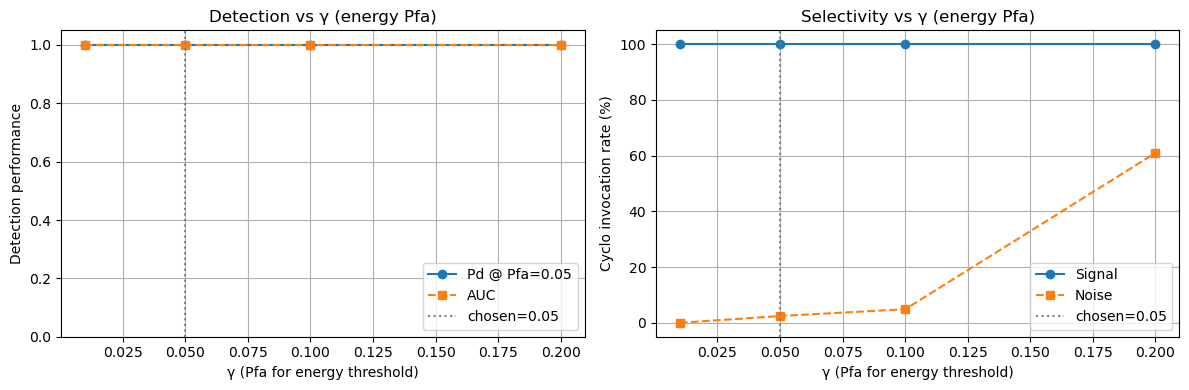

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/sensitivity_gamma.png


In [5]:
sweep_plot(
    param_vals=GAMMA_VALS,
    records=gamma_records,
    param_name="γ (energy Pfa)",
    param_label="γ (Pfa for energy threshold)",
    fname="sensitivity_gamma.png",
    fixed_marker=FIXED_PFA,
)

---
## Sweep 2: min_burst_len

Extends Phase 1 sweep (which covered [3, 10, 20, 50]) by adding mbl=100.  
Uses fixed γ=0.05 threshold.  
**Expected runtime: ~60–80 min**

In [6]:
MBL_VALS = [10, 20, 50, 100]
mbl_records = []

for mbl in MBL_VALS:
    print(f"\nmin_burst_len={mbl}")
    r = evaluate_cascade(thr=thr_fixed, mbl=mbl, nfft=FIXED_NFFT, label_str=f"mbl={mbl}")
    r["min_burst_len"] = mbl
    mbl_records.append(r)
    print(f"  AUC={r['AUC']:.3f}  Pd={r['Pd']:.3f}  "
          f"inv_signal={r['inv_signal']*100:.1f}%  inv_noise={r['inv_noise']*100:.1f}%")

df_mbl = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in mbl_records])
df_mbl.to_csv(OUT / "sensitivity_mbl.csv", index=False)
print("\n", df_mbl.to_string(index=False))


min_burst_len=10


mbl=10: 100%|██████████| 10/10 [04:04<00:00, 24.43s/it]


  AUC=1.000  Pd=1.000  inv_signal=100.0%  inv_noise=100.0%

min_burst_len=20


mbl=20: 100%|██████████| 10/10 [04:01<00:00, 24.14s/it]


  AUC=1.000  Pd=1.000  inv_signal=100.0%  inv_noise=100.0%

min_burst_len=50


mbl=50: 100%|██████████| 10/10 [03:45<00:00, 22.54s/it]


  AUC=1.000  Pd=1.000  inv_signal=100.0%  inv_noise=2.4%

min_burst_len=100


mbl=100: 100%|██████████| 10/10 [03:46<00:00, 22.60s/it]

  AUC=1.000  Pd=1.000  inv_signal=100.0%  inv_noise=0.0%

  AUC  Pd  Pfa_op  inv_signal  inv_noise  min_burst_len
 1.0 1.0     0.0         1.0    1.00000             10
 1.0 1.0     0.0         1.0    1.00000             20
 1.0 1.0     0.0         1.0    0.02439             50
 1.0 1.0     0.0         1.0    0.00000            100


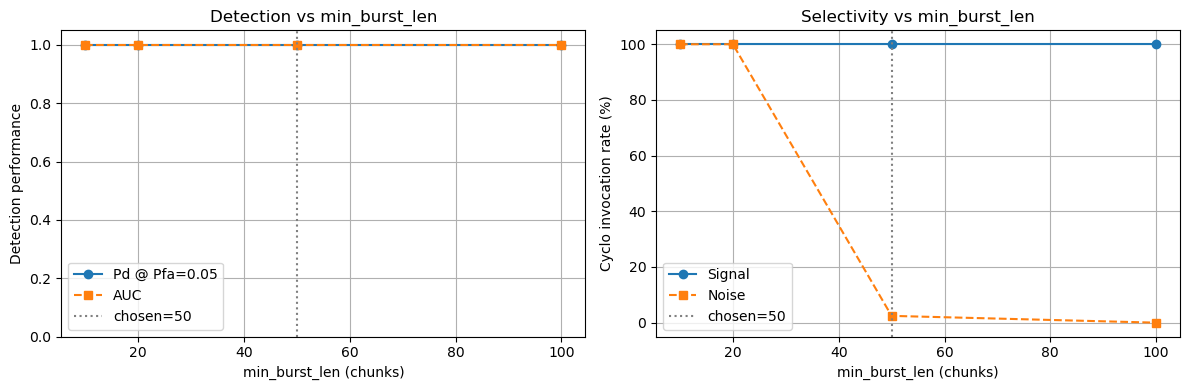

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/sensitivity_mbl.png


In [7]:
sweep_plot(
    param_vals=MBL_VALS,
    records=mbl_records,
    param_name="min_burst_len",
    param_label="min_burst_len (chunks)",
    fname="sensitivity_mbl.png",
    fixed_marker=FIXED_MBL,
)

---
## Sweep 3: Nfft (SCF window size)

Varies the STFT frame size used in the SCF-based cyclostationary detector.  
Cyclo is applied to concatenated burst chunks (large signal, so all Nfft values are valid).  
**Expected runtime: ~60–80 min**

In [8]:
NFFT_VALS = [128, 256, 512, 1024]
nfft_records = []

for nfft in NFFT_VALS:
    print(f"\nNfft={nfft}  (cyclic freq resolution = {FS_HZ/nfft/1e3:.1f} kHz)")
    r = evaluate_cascade(thr=thr_fixed, mbl=FIXED_MBL, nfft=nfft, label_str=f"Nfft={nfft}")
    r["Nfft"] = nfft
    r["cyclic_res_kHz"] = FS_HZ / nfft / 1e3
    nfft_records.append(r)
    print(f"  AUC={r['AUC']:.3f}  Pd={r['Pd']:.3f}  "
          f"inv_signal={r['inv_signal']*100:.1f}%  inv_noise={r['inv_noise']*100:.1f}%")

df_nfft = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in nfft_records])
df_nfft.to_csv(OUT / "sensitivity_nfft.csv", index=False)
print("\n", df_nfft.to_string(index=False))


Nfft=128  (cyclic freq resolution = 625.0 kHz)


Nfft=128: 100%|██████████| 10/10 [05:02<00:00, 30.22s/it]


  AUC=1.000  Pd=1.000  inv_signal=100.0%  inv_noise=2.4%

Nfft=256  (cyclic freq resolution = 312.5 kHz)


Nfft=256: 100%|██████████| 10/10 [04:10<00:00, 25.03s/it]


  AUC=1.000  Pd=1.000  inv_signal=100.0%  inv_noise=2.4%

Nfft=512  (cyclic freq resolution = 156.2 kHz)


Nfft=512: 100%|██████████| 10/10 [03:53<00:00, 23.35s/it]


  AUC=1.000  Pd=1.000  inv_signal=100.0%  inv_noise=2.4%

Nfft=1024  (cyclic freq resolution = 78.1 kHz)


Nfft=1024: 100%|██████████| 10/10 [03:35<00:00, 21.56s/it]

  AUC=1.000  Pd=1.000  inv_signal=100.0%  inv_noise=2.4%

  AUC  Pd  Pfa_op  inv_signal  inv_noise  Nfft  cyclic_res_kHz
 1.0 1.0     0.0         1.0    0.02439   128         625.000
 1.0 1.0     0.0         1.0    0.02439   256         312.500
 1.0 1.0     0.0         1.0    0.02439   512         156.250
 1.0 1.0     0.0         1.0    0.02439  1024          78.125


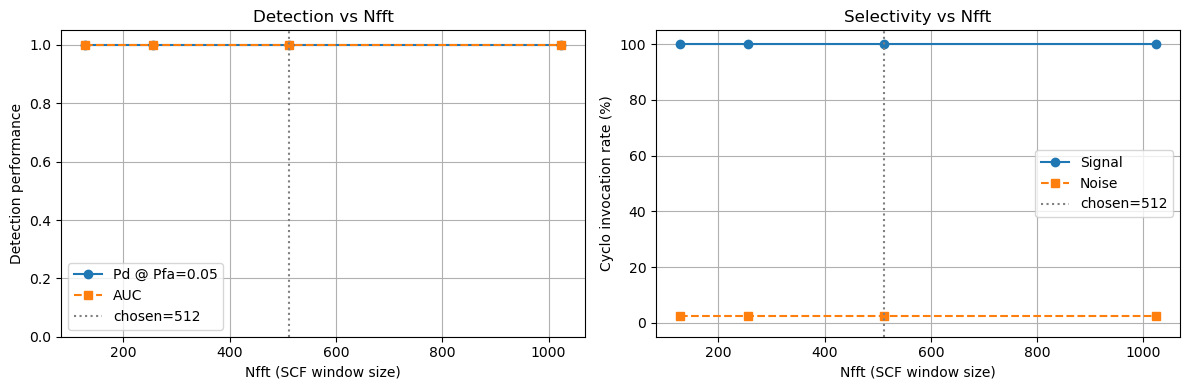

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/sensitivity_nfft.png


In [9]:
sweep_plot(
    param_vals=NFFT_VALS,
    records=nfft_records,
    param_name="Nfft",
    param_label="Nfft (SCF window size)",
    fname="sensitivity_nfft.png",
    fixed_marker=FIXED_NFFT,
)

---
## Sweep 4: min_duration (segment-level aggregation)

The segment-level score for Energy and Wavelet baselines is the mean of the top-k chunk scores,  
where k = ⌈min_duration / chunk_dur⌉. This sweep shows sensitivity to that choice.

Precomputes energy chunk scores once (fast), then varies k — **Expected runtime: ~5 min**

In [10]:
print("Precomputing chunk-level energy scores for all segments...")
seg_energy_chunks = []  # list of (chunk_scores_array, label)

for bui in tqdm(BUI, desc="Energy precompute"):
    label = get_binary_label(bui)
    for seg in range(get_segment_count(bui)):
        files = sorted(glob(str(CHUNKED_PATH / f"{bui}*_{seg}.npz")))
        if not files:
            continue
        scores = []
        for fp in files:
            chunks = np.load(fp)["arr_0"]
            scores.extend(energy_detector(x) for x in chunks)
        seg_energy_chunks.append((np.array(scores), label))

print(f"Segments loaded: {len(seg_energy_chunks)}")

Precomputing chunk-level energy scores for all segments...


Energy precompute: 100%|██████████| 10/10 [00:34<00:00,  3.43s/it]

Segments loaded: 227


In [11]:
def duration_constrained_score(scores, min_duration):
    k = max(1, int(np.ceil(min_duration / CHUNK_DUR)))
    if len(scores) <= k:
        return float(np.mean(scores))
    return float(np.mean(np.sort(scores)[-k:]))


MINDUR_VALS = [0.005, 0.025, 0.10, 0.50]  # seconds
dur_records = []

for min_dur in MINDUR_VALS:
    k = max(1, int(np.ceil(min_dur / CHUNK_DUR)))
    print(f"\nmin_duration={min_dur}s  →  k={k} chunks")
    seg_scores = np.array([duration_constrained_score(s, min_dur) for s, _ in seg_energy_chunks])
    seg_labels = np.array([lbl for _, lbl in seg_energy_chunks])

    fpr, tpr, _ = roc_curve(seg_labels, seg_scores)
    roc_auc = auc(fpr, tpr)
    ok = np.where(fpr <= FIXED_PFA)[0]
    i  = ok[np.argmax(tpr[ok])] if len(ok) else np.argmin(fpr)

    r = {
        "min_duration": min_dur,
        "k_chunks":     k,
        "AUC":          roc_auc,
        "Pd":           float(tpr[i]),
        "Pfa_op":       float(fpr[i]),
        "_fpr": fpr, "_tpr": tpr,
    }
    dur_records.append(r)
    print(f"  AUC={roc_auc:.3f}  Pd={float(tpr[i]):.3f}  Pfa={float(fpr[i]):.3f}")

df_dur = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in dur_records])
df_dur.to_csv(OUT / "sensitivity_duration.csv", index=False)
print("\n", df_dur.to_string(index=False))


min_duration=0.005s  →  k=100 chunks
  AUC=1.000  Pd=1.000  Pfa=0.000

min_duration=0.025s  →  k=500 chunks
  AUC=1.000  Pd=1.000  Pfa=0.000

min_duration=0.1s  →  k=2000 chunks
  AUC=1.000  Pd=1.000  Pfa=0.000

min_duration=0.5s  →  k=10000 chunks
  AUC=1.000  Pd=1.000  Pfa=0.000

  min_duration  k_chunks  AUC  Pd  Pfa_op
        0.005       100  1.0 1.0     0.0
        0.025       500  1.0 1.0     0.0
        0.100      2000  1.0 1.0     0.0
        0.500     10000  1.0 1.0     0.0


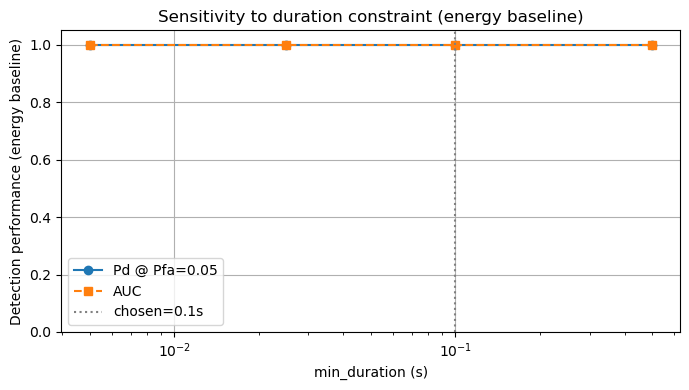

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/sensitivity_duration.png


In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(MINDUR_VALS, [r["Pd"]  for r in dur_records], "o-", label="Pd @ Pfa=0.05")
ax.plot(MINDUR_VALS, [r["AUC"] for r in dur_records], "s--", label="AUC")
ax.axvline(FIXED_MINDUR, color="gray", linestyle=":", label=f"chosen={FIXED_MINDUR}s")
ax.set_xlabel("min_duration (s)")
ax.set_ylabel("Detection performance (energy baseline)")
ax.set_xscale("log")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True)
ax.set_title("Sensitivity to duration constraint (energy baseline)")
fig.tight_layout()
fig.savefig(OUT / "sensitivity_duration.png", dpi=150)
plt.show()
print(f"Saved: {OUT / 'sensitivity_duration.png'}")

---
## Summary

In [13]:
print("=== γ sweep ===")
print(df_gamma[["pfa_gamma", "AUC", "Pd", "inv_signal", "inv_noise"]].to_string(index=False))
print("\n=== min_burst_len sweep ===")
print(df_mbl[["min_burst_len", "AUC", "Pd", "inv_signal", "inv_noise"]].to_string(index=False))
print("\n=== Nfft sweep ===")
print(df_nfft[["Nfft", "cyclic_res_kHz", "AUC", "Pd", "inv_signal", "inv_noise"]].to_string(index=False))
print("\n=== duration sweep ===")
print(df_dur[["min_duration", "k_chunks", "AUC", "Pd"]].to_string(index=False))
print("\nAll CSVs saved to:", OUT)

=== γ sweep ===
 pfa_gamma  AUC  Pd  inv_signal  inv_noise
      0.01  1.0 1.0         1.0   0.000000
      0.05  1.0 1.0         1.0   0.024390
      0.10  1.0 1.0         1.0   0.048780
      0.20  1.0 1.0         1.0   0.609756

=== min_burst_len sweep ===
 min_burst_len  AUC  Pd  inv_signal  inv_noise
            10  1.0 1.0         1.0    1.00000
            20  1.0 1.0         1.0    1.00000
            50  1.0 1.0         1.0    0.02439
           100  1.0 1.0         1.0    0.00000

=== Nfft sweep ===
 Nfft  cyclic_res_kHz  AUC  Pd  inv_signal  inv_noise
  128         625.000  1.0 1.0         1.0    0.02439
  256         312.500  1.0 1.0         1.0    0.02439
  512         156.250  1.0 1.0         1.0    0.02439
 1024          78.125  1.0 1.0         1.0    0.02439

=== duration sweep ===
 min_duration  k_chunks  AUC  Pd
        0.005       100  1.0 1.0
        0.025       500  1.0 1.0
        0.100      2000  1.0 1.0
        0.500     10000  1.0 1.0

All CSVs saved to: /home/